> ⚠️ **Historical Reference Note:** This notebook uses historical V2 models (e.g., est_model.pkl, xgb_model.pkl, lgb_model.pkl). The final production deployment uses the V3 models located in models/v3/.

# 🔮 Phase 7 — Future Forecasting (Recursive Multi-Step)

**Bank Cash Optimization Project**  
Past data (Feb 2024 – Apr 2026) ke basis par **agle 30 din** ka branch-wise cash withdrawal predict karna.

---

## Step 1: Libraries & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

# ─── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#c0c0d0',
    'xtick.color':      '#c0c0d0',
    'ytick.color':      '#c0c0d0',
    'text.color':       '#e0e0f0',
    'grid.color':       '#2a2a3e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

os.makedirs('eda_plots', exist_ok=True)
os.makedirs('models',    exist_ok=True)

# ─── Forecast Config ─────────────────────────────────────────────────────────
FORECAST_DAYS      = 30   # agle kitne din predict karne hain
HISTORY_PLOT_DAYS  = 60   # plot mein kitne past days dikhane hain

print(f'Config: Forecast = {FORECAST_DAYS} days, History shown = {HISTORY_PLOT_DAYS} days')
print('Libraries loaded.')

Config: Forecast = 30 days, History shown = 60 days
Libraries loaded.


---
## Step 2: Load Model & Historical Data

In [2]:
# ─── Load Model ──────────────────────────────────────────────────────────────
model = joblib.load('models/best_model.pkl')
print(f'Model: {type(model).__name__}')

with open('model_data/feature_cols.json') as f:
    feature_cols = json.load(f)
print(f'Features ({len(feature_cols)}): {feature_cols}')

# ─── Load Full Historical Data ────────────────────────────────────────────────
df = pd.read_csv('model_data/daily_full.csv', parse_dates=['start_date'])
df = df.sort_values(['tran_br_code', 'start_date']).reset_index(drop=True)

BRANCHES  = sorted(df['tran_br_code'].unique().tolist())
LAST_DATE = df['start_date'].max()

print(f'\nHistorical data: {df["start_date"].min().date()} to {LAST_DATE.date()}')
print(f'Branches ({len(BRANCHES)}): {BRANCHES}')
print(f'Forecast will start from: {(LAST_DATE + pd.Timedelta(days=1)).date()}')

Model: XGBRegressor
Features (22): ['tran_br_code', 'Daily_Txn_Count', 'Weekday', 'Is_Weekend', 'Month', 'Year', 'Day', 'Weekday_Sin', 'Weekday_Cos', 'Month_Sin', 'Month_Cos', 'Branch_Total_Debit', 'Branch_Txn_Count', 'Branch_Avg_Net_CF', 'Peak_Hour_Txns', 'Business_Hour_Txns', 'lag_1_debit', 'lag_7_debit', 'lag_14_debit', 'lag_30_debit', 'rolling_7_mean_debit', 'rolling_30_mean_debit']



Historical data: 2024-02-07 to 2026-04-04
Branches (15): [104, 202, 234, 287, 372, 394, 511, 593, 659, 1046, 1092, 1200, 1297, 1376, 1739]
Forecast will start from: 2026-04-05


---
## Step 3: Branch Averages (for Unknown Future Features)

In [3]:
# Features jo future mein unknown hain — branch-wise historical average use karein ge
UNKNOWN_FUTURE_COLS = [
    'Daily_Txn_Count', 'Branch_Total_Debit', 'Branch_Txn_Count',
    'Branch_Avg_Net_CF', 'Peak_Hour_Txns', 'Business_Hour_Txns'
]

branch_avgs = df.groupby('tran_br_code')[UNKNOWN_FUTURE_COLS].mean()
print('Branch averages computed:')
print(branch_avgs[['Daily_Txn_Count','Branch_Total_Debit']].round(0).to_string())

Branch averages computed:
              Daily_Txn_Count  Branch_Total_Debit
tran_br_code                                     
104                      10.0        7.464118e+10
202                       9.0        2.232957e+10
234                      10.0        2.413064e+10
287                       8.0        1.408842e+10
372                       9.0        1.924460e+10
394                       8.0        1.691733e+10
511                       9.0        1.846630e+10
593                       9.0        1.770667e+10
659                       9.0        1.711542e+10
1046                     10.0        6.078224e+10
1092                      9.0        2.556064e+10
1200                      9.0        2.900233e+10
1297                      9.0        3.814885e+10
1376                      8.0        2.681708e+10
1739                      9.0        1.235850e+10


---
## Step 4: Recursive Forecasting Engine

In [4]:
def get_calendar_features(date):
    """Calendar features jo hamesha calculate ho sakti hain."""
    weekday = date.weekday()          # 0=Mon … 6=Sun
    month   = date.month
    return {
        'Weekday'     : weekday,
        'Is_Weekend'  : int(weekday >= 5),
        'Month'       : month,
        'Year'        : date.year,
        'Day'         : date.day,
        'Weekday_Sin' : np.sin(2 * np.pi * weekday / 7),
        'Weekday_Cos' : np.cos(2 * np.pi * weekday / 7),
        'Month_Sin'   : np.sin(2 * np.pi * month / 12),
        'Month_Cos'   : np.cos(2 * np.pi * month / 12),
    }


def forecast_branch(branch_code, n_days=30):
    """
    Recursive multi-step forecast for a single branch.
    Returns DataFrame with columns: date, predicted, lower, upper, confidence
    """
    # Get this branch's history
    br_hist = df[df['tran_br_code'] == branch_code].sort_values('start_date').copy()
    br_avgs = branch_avgs.loc[branch_code]
    
    # Build a deque of recent debit values for lag calculations
    # We need values going back 30 days from last known date
    debit_history = br_hist[['start_date', 'Daily_Total_Debit']].copy()
    debit_history = debit_history.set_index('start_date')['Daily_Total_Debit']
    
    last_date = br_hist['start_date'].max()
    
    results = []
    
    for step in range(1, n_days + 1):
        target_date = last_date + pd.Timedelta(days=step)
        
        # ── Lag features ──────────────────────────────────────────────────────
        def get_lag(lag_days):
            lag_date = target_date - pd.Timedelta(days=lag_days)
            if lag_date in debit_history.index:
                return debit_history[lag_date]
            else:
                # Use last available value as fallback
                available = debit_history[debit_history.index <= lag_date]
                return available.iloc[-1] if len(available) > 0 else debit_history.iloc[-1]
        
        lag_1  = get_lag(1)
        lag_7  = get_lag(7)
        lag_14 = get_lag(14)
        lag_30 = get_lag(30)
        
        # ── Rolling means ─────────────────────────────────────────────────────
        recent_7  = []
        recent_30 = []
        for d in range(1, 8):
            dt = target_date - pd.Timedelta(days=d)
            if dt in debit_history.index:
                recent_7.append(debit_history[dt])
                recent_30.append(debit_history[dt])
        for d in range(8, 31):
            dt = target_date - pd.Timedelta(days=d)
            if dt in debit_history.index:
                recent_30.append(debit_history[dt])
        
        rolling_7_mean  = np.mean(recent_7)  if recent_7  else lag_7
        rolling_30_mean = np.mean(recent_30) if recent_30 else lag_30
        
        # ── Calendar features ─────────────────────────────────────────────────
        cal = get_calendar_features(target_date)
        
        # ── Build feature row ─────────────────────────────────────────────────
        row = {
            'tran_br_code'        : branch_code,
            'Daily_Txn_Count'     : br_avgs['Daily_Txn_Count'],
            'Branch_Total_Debit'  : br_avgs['Branch_Total_Debit'],
            'Branch_Txn_Count'    : br_avgs['Branch_Txn_Count'],
            'Branch_Avg_Net_CF'   : br_avgs['Branch_Avg_Net_CF'],
            'Peak_Hour_Txns'      : br_avgs['Peak_Hour_Txns'],
            'Business_Hour_Txns'  : br_avgs['Business_Hour_Txns'],
            'lag_1_debit'         : lag_1,
            'lag_7_debit'         : lag_7,
            'lag_14_debit'        : lag_14,
            'lag_30_debit'        : lag_30,
            'rolling_7_mean_debit': rolling_7_mean,
            'rolling_30_mean_debit': rolling_30_mean,
            **cal
        }
        
        X = pd.DataFrame([row])[feature_cols]
        prediction = float(model.predict(X)[0])
        prediction = max(prediction, 0)   # no negative cash
        
        # ── Uncertainty grows with horizon ────────────────────────────────────
        uncertainty_pct = 0.05 + (step - 1) * (0.20 / n_days)  # 5% → 25%
        lower = prediction * (1 - uncertainty_pct)
        upper = prediction * (1 + uncertainty_pct)
        
        if step <= 7:
            confidence = 'HIGH'
        elif step <= 14:
            confidence = 'MEDIUM'
        else:
            confidence = 'LOW'
        
        results.append({
            'Branch'        : branch_code,
            'Date'          : target_date,
            'Predicted_PKR' : round(prediction),
            'Predicted_M'   : round(prediction / 1e6, 2),
            'Lower_M'       : round(lower / 1e6, 2),
            'Upper_M'       : round(upper / 1e6, 2),
            'Uncertainty_Pct': round(uncertainty_pct * 100, 1),
            'Confidence'    : confidence,
            'Step'          : step,
        })
        
        # ── Add prediction to history for next step ──────────────────────────
        debit_history[target_date] = prediction
    
    return pd.DataFrame(results)


print('Recursive forecasting engine ready!')

Recursive forecasting engine ready!


In [5]:
# ─── Run Forecast for All Branches ───────────────────────────────────────────
all_forecasts = []

for branch in BRANCHES:
    fc = forecast_branch(branch, n_days=FORECAST_DAYS)
    all_forecasts.append(fc)
    print(f'Branch {branch:>5} → {len(fc)} days forecasted | '
          f'Week1 avg: {fc[fc["Step"]<=7]["Predicted_M"].mean():.1f}M | '
          f'Week4 avg: {fc[fc["Step"]>21]["Predicted_M"].mean():.1f}M')

forecast_df = pd.concat(all_forecasts, ignore_index=True)
print(f'\nTotal forecast rows: {len(forecast_df)}')
print(f'Forecast period: {forecast_df["Date"].min().date()} to {forecast_df["Date"].max().date()}')

Branch   104 → 30 days forecasted | Week1 avg: 108.7M | Week4 avg: 96.0M


Branch   202 → 30 days forecasted | Week1 avg: 37.5M | Week4 avg: 32.4M


Branch   234 → 30 days forecasted | Week1 avg: 43.8M | Week4 avg: 44.0M


Branch   287 → 30 days forecasted | Week1 avg: 22.8M | Week4 avg: 20.4M


Branch   372 → 30 days forecasted | Week1 avg: 28.2M | Week4 avg: 25.8M


...

Branch  1092 → 30 days forecasted | Week1 avg: 36.4M | Week4 avg: 33.4M


Branch  1200 → 30 days forecasted | Week1 avg: 61.9M | Week4 avg: 56.6M


Branch  1297 → 30 days forecasted | Week1 avg: 60.6M | Week4 avg: 64.3M


Branch  1376 → 30 days forecasted | Week1 avg: 45.0M | Week4 avg: 47.5M


Branch  1739 → 30 days forecasted | Week1 avg: 23.2M | Week4 avg: 21.7M

Total forecast rows: 450
Forecast period: 2026-04-04 to 2026-05-04


---
## Step 5: Plot 22 — All Branches 30-Day Forecast Overview

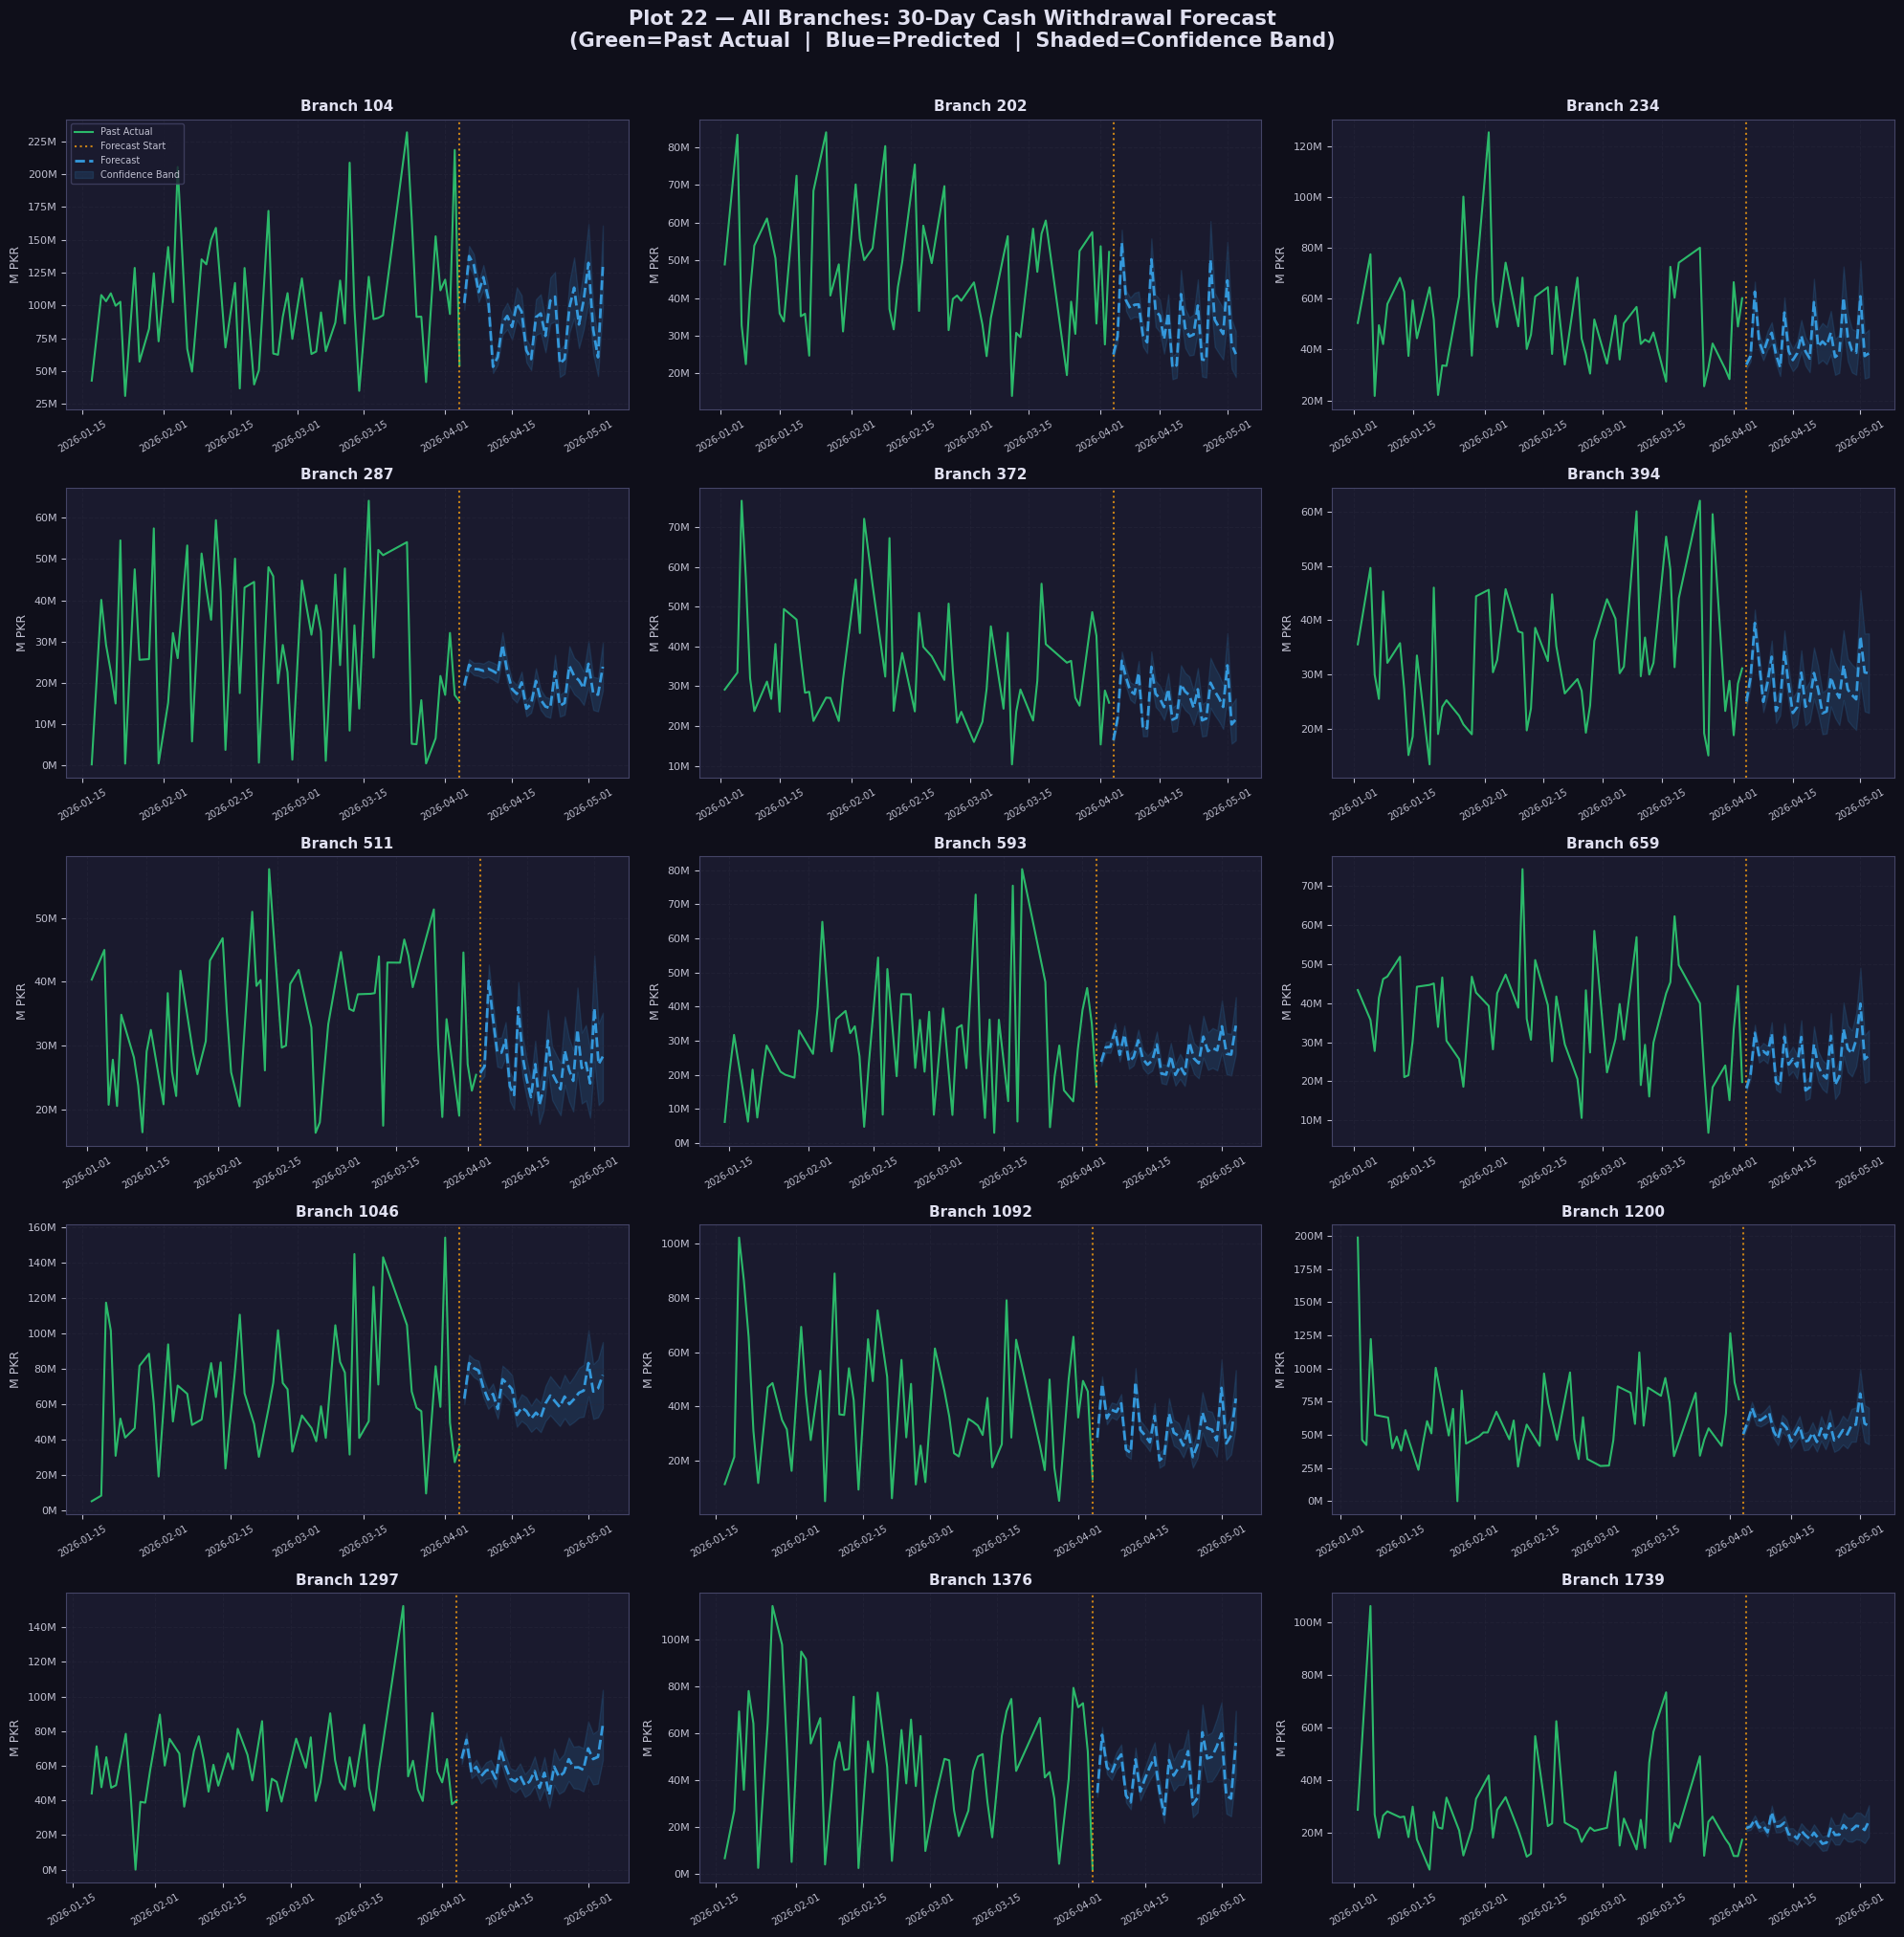

Plot 22 saved: eda_plots/22_all_branches_forecast.png


In [6]:
# ─── Plot 22: Grid of all 15 branches ────────────────────────────────────────
n_branches = len(BRANCHES)
ncols = 3
nrows = (n_branches + ncols - 1) // ncols  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
fig.suptitle('Plot 22 — All Branches: 30-Day Cash Withdrawal Forecast\n'
             '(Green=Past Actual  |  Blue=Predicted  |  Shaded=Confidence Band)',
             fontsize=15, fontweight='bold', color='#e0e0f0', y=1.01)

axes_flat = axes.flatten()

for idx, branch in enumerate(BRANCHES):
    ax = axes_flat[idx]
    
    # Past history
    br_hist = df[df['tran_br_code'] == branch].sort_values('start_date').tail(HISTORY_PLOT_DAYS)
    past_dates = br_hist['start_date'].values
    past_vals  = br_hist['Daily_Total_Debit'].values / 1e6
    
    # Future forecast
    br_fc   = forecast_df[forecast_df['Branch'] == branch].sort_values('Date')
    fc_dates  = br_fc['Date'].values
    fc_vals   = br_fc['Predicted_M'].values
    fc_lower  = br_fc['Lower_M'].values
    fc_upper  = br_fc['Upper_M'].values
    
    # Plot past
    ax.plot(past_dates, past_vals, color='#2ecc71', linewidth=1.5,
            label='Past Actual', alpha=0.9)
    
    # Vertical divider
    ax.axvline(x=pd.Timestamp(LAST_DATE), color='#f39c12',
               linewidth=1.5, linestyle=':', alpha=0.8, label='Forecast Start')
    
    # Forecast line
    ax.plot(fc_dates, fc_vals, color='#3498db', linewidth=2,
            linestyle='--', label='Forecast', zorder=3)
    
    # Confidence ribbon
    ax.fill_between(fc_dates, fc_lower, fc_upper,
                    color='#3498db', alpha=0.15, label='Confidence Band')
    
    ax.set_title(f'Branch {branch}', color='#e0e0f0', fontsize=11, fontweight='bold')
    ax.set_ylabel('M PKR', color='#c0c0d0', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}M'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.4)
    
    if idx == 0:
        ax.legend(fontsize=7, facecolor='#1a1a2e', edgecolor='#444466',
                  labelcolor='#c0c0d0', loc='upper left')

# Hide empty subplots
for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('eda_plots/22_all_branches_forecast.png', dpi=120,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Plot 22 saved: eda_plots/22_all_branches_forecast.png')

---
## Step 6: Plot 23 — Top 6 Branches with Detailed Confidence Ribbons

Top 6 branches by volume: [104, 1046, 1297, 1200, 234, 1376]


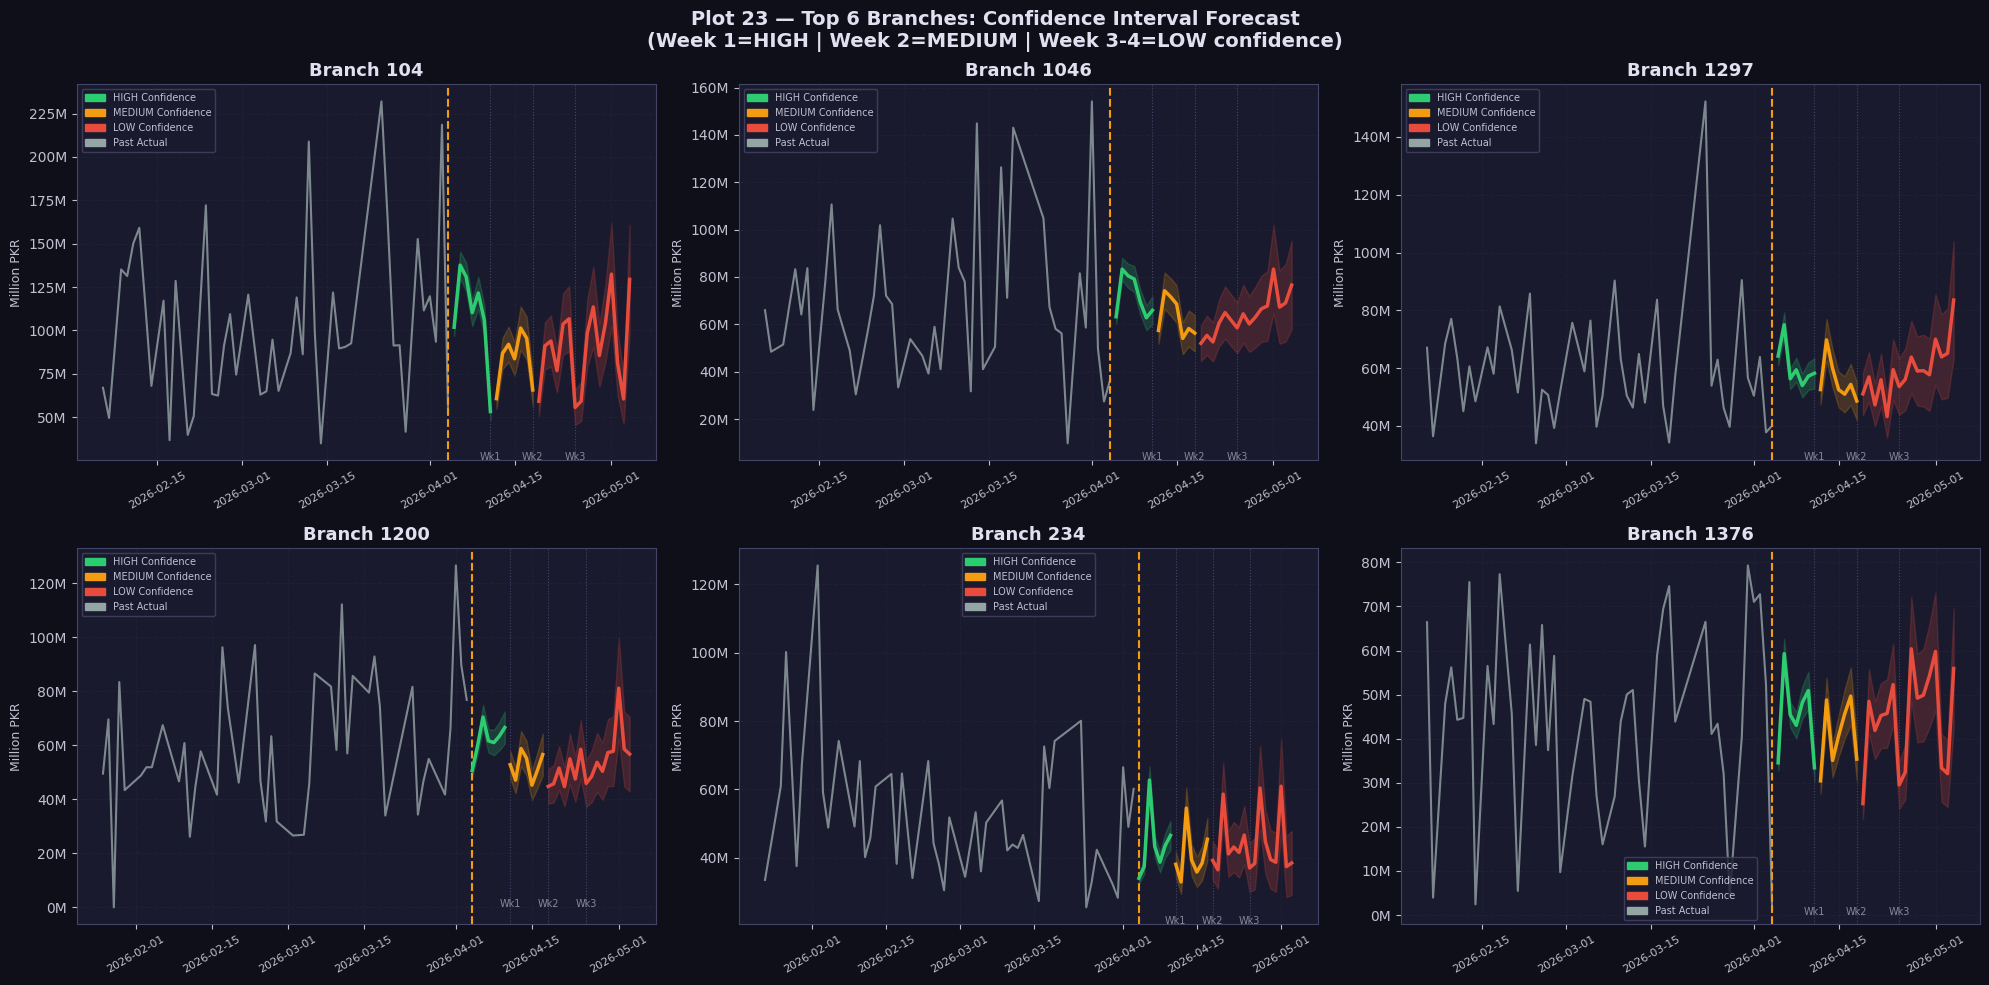

Plot 23 saved: eda_plots/23_confidence_ribbons.png


In [7]:
# Top 6 branches by average volume
top6 = (df.groupby('tran_br_code')['Daily_Total_Debit'].mean()
          .nlargest(6).index.tolist())
print(f'Top 6 branches by volume: {top6}')

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Plot 23 — Top 6 Branches: Confidence Interval Forecast\n'
             '(Week 1=HIGH | Week 2=MEDIUM | Week 3-4=LOW confidence)',
             fontsize=14, fontweight='bold', color='#e0e0f0')

axes_flat = axes.flatten()
CONF_COLORS = {'HIGH': '#2ecc71', 'MEDIUM': '#f39c12', 'LOW': '#e74c3c'}

for idx, branch in enumerate(top6):
    ax = axes_flat[idx]
    
    # Past 45 days
    br_hist = df[df['tran_br_code'] == branch].sort_values('start_date').tail(45)
    ax.plot(br_hist['start_date'], br_hist['Daily_Total_Debit'] / 1e6,
            color='#95a5a6', linewidth=1.5, alpha=0.8, label='Past (60d)')
    
    # Forecast — colored by confidence
    br_fc = forecast_df[forecast_df['Branch'] == branch].sort_values('Date')
    
    for conf, grp in br_fc.groupby('Confidence', sort=False):
        c = CONF_COLORS[conf]
        ax.plot(grp['Date'], grp['Predicted_M'],
                color=c, linewidth=2.5, label=f'{conf} conf', zorder=4)
        ax.fill_between(grp['Date'], grp['Lower_M'], grp['Upper_M'],
                        color=c, alpha=0.20)
    
    # Week markers
    for w, days in [(7, 'Wk1'), (14, 'Wk2'), (21, 'Wk3')]:
        wk_date = LAST_DATE + pd.Timedelta(days=w)
        ax.axvline(wk_date, color='#444466', linewidth=0.8, linestyle=':')
        ax.text(wk_date, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0,
                days, color='#888899', fontsize=7, ha='center')
    
    ax.axvline(LAST_DATE, color='#f39c12', linewidth=1.5, linestyle='--')
    ax.set_title(f'Branch {branch}', color='#e0e0f0', fontweight='bold')
    ax.set_ylabel('Million PKR', color='#c0c0d0', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}M'))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(True, alpha=0.4)
    
    # Custom legend
    patches = [mpatches.Patch(color=c, label=f'{l} Confidence')
               for l, c in CONF_COLORS.items()]
    patches.append(mpatches.Patch(color='#95a5a6', label='Past Actual'))
    ax.legend(handles=patches, fontsize=7, facecolor='#1a1a2e',
              edgecolor='#444466', labelcolor='#c0c0d0')

plt.tight_layout()
plt.savefig('eda_plots/23_confidence_ribbons.png', dpi=130,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Plot 23 saved: eda_plots/23_confidence_ribbons.png')

---
## Step 7: Plot 24 — Heatmap (Branch × Date Forecast Matrix)

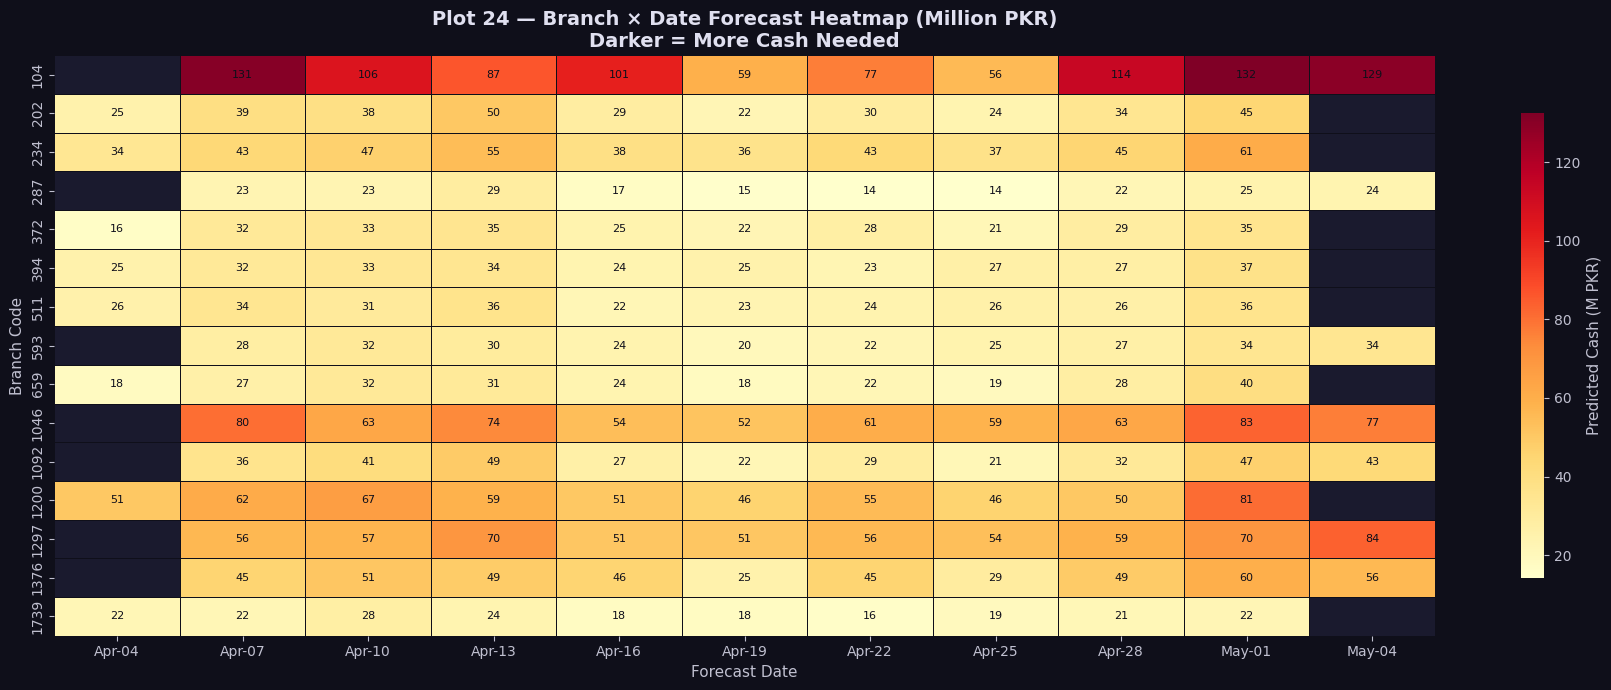

Plot 24 saved: eda_plots/24_forecast_heatmap.png


In [8]:
# ─── Pivot to heatmap ────────────────────────────────────────────────────────
heat_pivot = forecast_df.pivot_table(
    index='Branch', columns='Date', values='Predicted_M'
)
heat_pivot.columns = [d.strftime('%b-%d') for d in heat_pivot.columns]
heat_pivot.index   = heat_pivot.index.astype(str)

# Show every 3rd column for readability
col_mask = [i % 3 == 0 for i in range(len(heat_pivot.columns))]
heat_display = heat_pivot.iloc[:, col_mask]

fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

sns.heatmap(
    heat_display,
    ax=ax,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    linecolor='#0f0f1a',
    annot_kws={'size': 8, 'color': '#0f0f1a'},
    cbar_kws={'label': 'Predicted Cash (M PKR)', 'shrink': 0.8}
)

ax.set_title('Plot 24 — Branch × Date Forecast Heatmap (Million PKR)\n'
             'Darker = More Cash Needed',
             color='#e0e0f0', fontsize=14, fontweight='bold')
ax.set_xlabel('Forecast Date', color='#c0c0d0', fontsize=11)
ax.set_ylabel('Branch Code',   color='#c0c0d0', fontsize=11)
ax.tick_params(colors='#c0c0d0')

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color('#c0c0d0')
cbar.ax.tick_params(colors='#c0c0d0')

plt.tight_layout()
plt.savefig('eda_plots/24_forecast_heatmap.png', dpi=130,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Plot 24 saved: eda_plots/24_forecast_heatmap.png')

---
## Step 8: Weekly Summary Table

In [9]:
# ─── Weekly summary ──────────────────────────────────────────────────────────
def week_label(step):
    if step <= 7:  return 'Week1'
    if step <= 14: return 'Week2'
    if step <= 21: return 'Week3'
    return 'Week4'

forecast_df['Week'] = forecast_df['Step'].apply(week_label)

weekly = (forecast_df
          .groupby(['Branch', 'Week'])['Predicted_M']
          .agg(['mean', 'sum'])
          .round(1)
          .rename(columns={'mean': 'Daily_Avg_M', 'sum': 'Week_Total_M'})
          .reset_index()
         )

# Pivot for display
weekly_pivot = weekly.pivot_table(
    index='Branch', columns='Week',
    values='Daily_Avg_M'
)[['Week1', 'Week2', 'Week3', 'Week4']]

print('Weekly Average Daily Forecast (Million PKR):')
print(weekly_pivot.to_string())

Weekly Average Daily Forecast (Million PKR):
Week    Week1  Week2  Week3  Week4
Branch                                                        
104            108.7            83.6         83.8         96.0
202             37.5            35.1         30.7         32.4
234             43.8            40.7         43.8         44.0
287             22.8            20.5         16.7         20.4
372             28.2            26.1         26.4         25.8
394             30.4            26.8         26.0         29.0
511             30.8            26.3         25.3         28.0
593             27.8            25.2         23.2         28.6
659             26.6            25.1         23.4         28.0
1046            72.0            62.9         57.9         68.7
1092            36.4            30.9         28.2         33.4
1200            61.9            52.3         49.7         56.6
1297            60.6            55.5         52.5         64.3
1376            45.0            40.8  

---
## Step 9: Excel Export (Multi-Sheet)

In [10]:
excel_path = 'models/forecast_next30days.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    
    # Sheet 1: All branches summary
    summary_cols = ['Branch', 'Date', 'Predicted_M', 'Lower_M', 'Upper_M',
                    'Uncertainty_Pct', 'Confidence', 'Step']
    forecast_df[summary_cols].to_excel(writer, sheet_name='All_Branches', index=False)
    
    # Sheet 2: Weekly pivot
    weekly_pivot.to_excel(writer, sheet_name='Weekly_Summary')
    
    # Sheet 3–N: Per-branch
    for branch in BRANCHES:
        br_fc = forecast_df[forecast_df['Branch'] == branch][summary_cols].copy()
        br_fc['Date'] = br_fc['Date'].dt.strftime('%Y-%m-%d')
        sheet_name = f'Br_{branch}'
        br_fc.to_excel(writer, sheet_name=sheet_name, index=False)

print(f'Excel saved: {excel_path}')
print(f'Sheets: All_Branches, Weekly_Summary + {len(BRANCHES)} branch sheets')
print(f'File size: {os.path.getsize(excel_path):,} bytes')

Excel saved: models/forecast_next30days.xlsx
Sheets: All_Branches, Weekly_Summary + 15 branch sheets
File size: 53,895 bytes


---
## Step 10: Final Summary

In [11]:
print('=' * 65)
print('PHASE 7 — FUTURE FORECASTING COMPLETE')
print('=' * 65)
print(f'  Forecast period : {forecast_df["Date"].min().date()} to {forecast_df["Date"].max().date()}')
print(f'  Branches        : {len(BRANCHES)}')
print(f'  Total rows      : {len(forecast_df)}')
print()
print('  TOTAL PREDICTED CASH NEED (ALL BRANCHES, 30 DAYS):')
total_30 = forecast_df['Predicted_M'].sum()
print(f'  {total_30:,.1f} Million PKR = {total_30/1000:.2f} Billion PKR')
print()
print('  Per-week breakdown (all branches combined):')
for wk in ['Week1', 'Week2', 'Week3', 'Week4']:
    wk_total = forecast_df[forecast_df['Week'] == wk]['Predicted_M'].sum()
    print(f'    {wk:22s}: {wk_total:>8,.1f} M PKR')
print()
print('  Files saved:')
print('    eda_plots/22_all_branches_forecast.png')
print('    eda_plots/23_confidence_ribbons.png')
print('    eda_plots/24_forecast_heatmap.png')
print('    models/forecast_next30days.xlsx')
print('    explanation/Phase_7_Future_Forecasting.md')
print('=' * 65)

PHASE 7 — FUTURE FORECASTING COMPLETE
  Forecast period : 2026-04-04 to 2026-05-04
  Branches        : 15
  Total rows      : 450

  TOTAL PREDICTED CASH NEED (ALL BRANCHES, 30 DAYS):
  18,049.1 Million PKR = 18.05 Billion PKR

  Per-week breakdown (all branches combined):
    Week1          :  4,589.7 M PKR
    Week2        :  4,009.6 M PKR
    Week3           :  3,830.8 M PKR
    Week4           :  5,619.1 M PKR

  Files saved:
    eda_plots/22_all_branches_forecast.png
    eda_plots/23_confidence_ribbons.png
    eda_plots/24_forecast_heatmap.png
    models/forecast_next30days.xlsx
    explanation/Phase_7_Future_Forecasting.md


In [12]:
# ─── Generate MD Report ───────────────────────────────────────────────────────
import datetime

# Collect key numbers for the report
total_all = forecast_df['Predicted_M'].sum()
week1_total = forecast_df[forecast_df['Week']=='Week1']['Predicted_M'].sum()
top_branch = forecast_df.groupby('Branch')['Predicted_M'].mean().idxmax()
top_branch_avg = forecast_df.groupby('Branch')['Predicted_M'].mean().max()

wk_pivot = weekly_pivot.reset_index()

md = []
md.append('# Forecasting Report\n')
md.append(f'*Generated: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}*\n\n')
md.append('---\n\n')
md.append('## Summary\n')
md.append(f'- **Forecast period:** {forecast_df["Date"].min().date()} to {forecast_df["Date"].max().date()}\n')
md.append(f'- **Branches:** {len(BRANCHES)}\n')
md.append(f'- **Total 30-day cash need:** {total_all:,.1f} M PKR ({total_all/1000:.2f} B PKR)\n')
md.append(f'- **Week 1 (HIGH confidence):** {week1_total:,.1f} M PKR\n')
md.append(f'- **Highest demand branch:** {top_branch} (avg {top_branch_avg:.1f}M/day)\n')
md.append('\n---\n\n')
md.append('## Weekly Average Daily Forecast (Million PKR)\n\n')
md.append('| Branch | Week1 HIGH | Week2 MED | Week3 LOW | Week4 LOW |\n')
md.append('|---|---|---|---|---|\n')
for _, r in wk_pivot.iterrows():
    w1 = r.get('Week1', 'N/A')
    w2 = r.get('Week2', 'N/A')
    w3 = r.get('Week3', 'N/A')
    w4 = r.get('Week4', 'N/A')
    md.append(f'| {int(r["Branch"])} | {w1} | {w2} | {w3} | {w4} |\n')
md.append('\n---\n\n')
md.append('## Files Generated\n\n')
md.append('| File | Description |\n|---|---|\n')
md.append('| `eda_plots/22_all_branches_forecast.png` | All 15 branches forecast grid |\n')
md.append('| `eda_plots/23_confidence_ribbons.png` | Top 6 branches confidence ribbons |\n')
md.append('| `eda_plots/24_forecast_heatmap.png` | Branch x date heatmap |\n')
md.append('| `models/forecast_next30days.xlsx` | Full forecast Excel (17 sheets) |\n')

os.makedirs('explanation', exist_ok=True)
with open('explanation/Phase_7_Future_Forecasting.md', 'w', encoding='utf-8') as f:
    f.writelines(md)

print('MD report saved: explanation/Phase_7_Future_Forecasting.md')
print('Phase 7 COMPLETE!')

MD report saved: explanation/Phase_7_Future_Forecasting.md
Phase 7 COMPLETE!
